In [181]:
import pandas as pd
import duckdb as db
import seaborn as sns
import plotly
import matplotlib.pyplot as plt
import numpy as np

In [182]:
fake_df = pd.read_csv(r"D:\IT\Python\fake-news-detection\data\Fake.csv\Fake.csv")
true_df = pd.read_csv(r"D:\IT\Python\fake-news-detection\data\True.csv\True.csv")

In [183]:
fake_df['is_fake'] = 1
true_df['is_fake'] = 0

In [184]:
fake_df.isna().sum()[fake_df.isna().sum()>0], true_df.isna().sum()[true_df.isna().sum()>0]

(Series([], dtype: int64), Series([], dtype: int64))

In [185]:
print(fake_df.duplicated().sum())
print(true_df.duplicated().sum())

3
206


In [186]:
df = pd.concat([fake_df, true_df])

In [30]:
df.shape

(39105, 5)

In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 39105 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    39105 non-null  str  
 1   text     39105 non-null  str  
 2   subject  39105 non-null  str  
 3   date     39105 non-null  str  
 4   is_fake  39105 non-null  int64
dtypes: int64(1), str(4)
memory usage: 96.5 MB


In [187]:
df['is_fake'].value_counts(normalize=True)

is_fake
1    0.522985
0    0.477015
Name: proportion, dtype: float64

In [188]:
df.head()

,title,text,subject,date,is_fake
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [189]:
df.duplicated(subset=["text", 'title']).sum()

np.int64(5793)

In [190]:
df = df.drop_duplicates(subset=["text", 'title'])

In [191]:
len(df)

39105

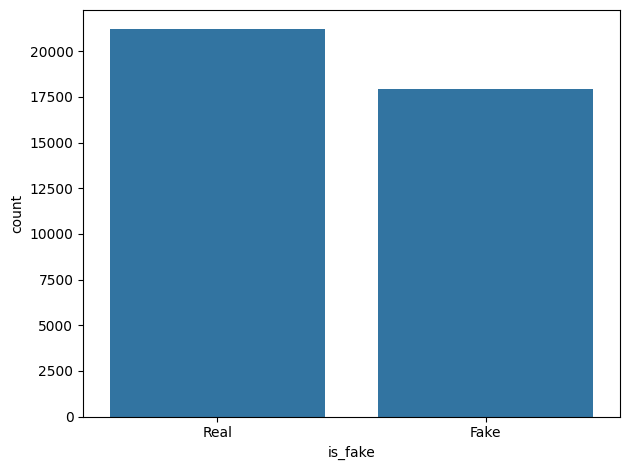

In [192]:
sns.countplot(data=df, x='is_fake')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.tight_layout()

In [193]:
subjects = df['subject'].value_counts()

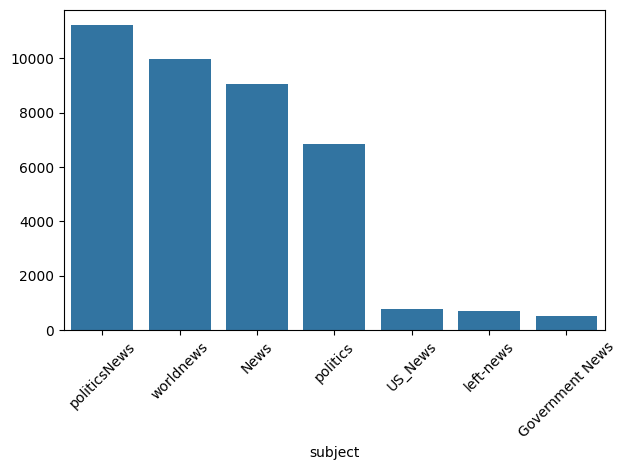

In [194]:
sns.barplot(x = subjects.index, y = subjects.values)
plt.xticks(rotation=45)
plt.tight_layout()

In [195]:
mask = df['date'].str.contains(r"^\d{1,2}-\w+-\d{2}$", regex=True)

In [196]:
df.loc[mask, 'date'] = pd.to_datetime(df.loc[mask, 'date'], format='%d-%b-%y').dt.strftime('%B %d, %Y')

In [197]:
mask1 = df['date'].str.contains(r"^\w{3} \d{1,2}, \d{4}$", regex=True)

In [198]:
df.loc[mask1, 'date'] = pd.to_datetime(df.loc[mask1, 'date'], format='%b %d, %Y').dt.strftime('%B %d, %Y')

In [199]:
df['date_clean'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

In [200]:
bad_dates_count = df['date_clean'].isna().sum()

In [201]:
df.isna().sum()[df.isna().sum()>0]

date_clean    6
dtype: int64

In [202]:
df = df.dropna(subset=['date_clean'])

In [203]:
df = df.drop('date', axis=1)
df = df.rename(columns = {'date_clean': 'date'})

<Axes: xlabel='date', ylabel='size'>

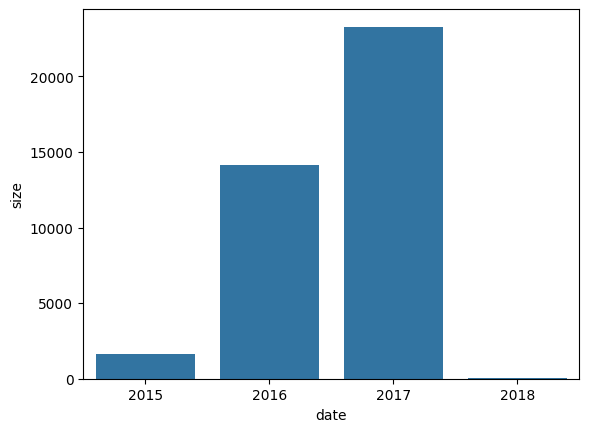

In [204]:
a = df.groupby(df['date'].dt.year, as_index=False).size()
sns.barplot(data=a, x='date', y='size')

In [205]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

<Axes: xlabel='word_count', ylabel='Count'>

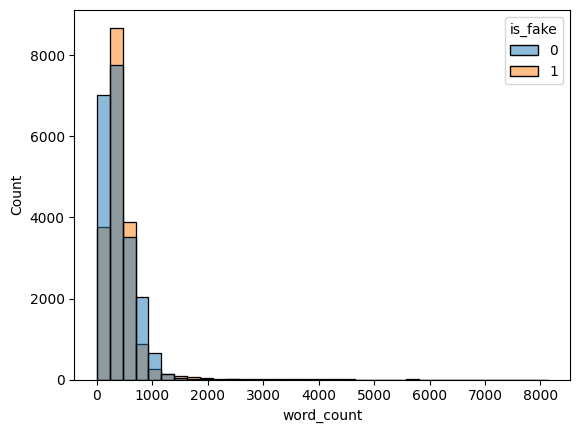

In [206]:
sns.histplot(data=df, x='word_count', bins=35, hue='is_fake')


In [207]:
df['character_count'] = df['text'].apply(lambda x: len(x))

<Axes: xlabel='character_count', ylabel='Count'>

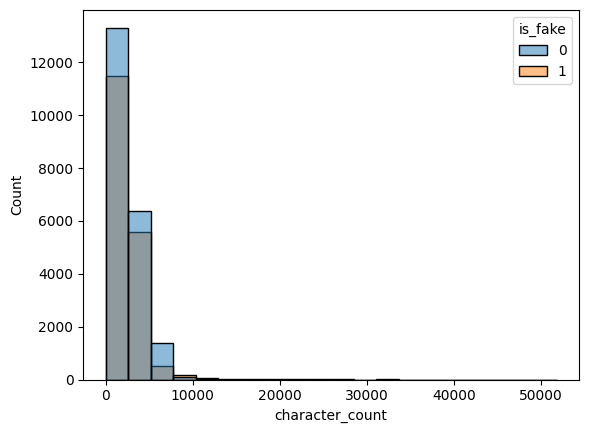

In [210]:
sns.histplot(data=df, x='character_count', bins=20, hue='is_fake')